#Project 3B - Water Pipe Failure Prediction

**Authored by:**

1. **Ashley Mathew**
2. **Rupanshi**

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data cleaning, Data analysis, Data visualisation, Feature Tuning, Machine Learning, XGBoost, Random Forest

### Scenario

Water pipe failures are a significant and costly challenge for city utilities. When a pipe fails unexpectedly, it can cause major service disruptions, road damage, and expensive emergency repairs. Many cities still rely on a reactive approach which is only responding after a specific failure occurs rather than using data to predict and prevent failures before they happen.

In this project, we work on building a predictive system that analyses water pipe infrastructure data to identify pipes most at risk of failure. By examining factors such as pipe age, material type, soil conditions, and prior repair history, a few common patterns can be identified that allow maintenance teams to prioritise their resources and act before a failure occurs.

### Introduction

This project focuses on analysing historical water pipe infrastructure data and building machine learning models to predict pipe failure risk. The dataset includes key infrastructure attributes such as installation year, pipe material, soil condition, pipe diameter, and repair history.

New features are engineered from these attributeso capture domain-specific patterns that improve model performance. Two ensemble models, Random Forest and XGBoost, are then trained and compared on their ability to classify pipes as high or low failure risk. The best-performing model is used to generate a risk score for every pipe in the dataset, producing a prioritised maintenance shortlist for city utilities.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', 'imbalanced-learn', '-q'])

import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, accuracy_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

DRIVE_PATH = '/content/drive/MyDrive/Chameleon_Project3B'
RANDOM_STATE = 42

for folder in [DRIVE_PATH, f'{DRIVE_PATH}/data', f'{DRIVE_PATH}/models',
               f'{DRIVE_PATH}/outputs', f'{DRIVE_PATH}/reports']:
    os.makedirs(folder, exist_ok=True)

MATERIAL_LIFESPAN = {
    'cast_iron': 100, 'ductile_iron': 100, 'pvc': 75,
    'concrete': 75, 'steel': 70, 'asbestos_cement': 70,
    'galvanized_steel': 50, 'copper': 80, 'hdpe': 50, 'clay': 60
}

SOIL_CORROSIVITY_MAP = {
    'highly_corrosive': 5, 'corrosive': 4, 'moderately_corrosive': 3,
    'mildly_corrosive': 2, 'non_corrosive': 1
}

# Chameleon colour palette
COLORS = {
    'primary': '#0f9295',
    'secondary': '#08b3e5',
    'accent1': '#2af598',
    'accent2': '#1bd7bb',
    'dark': '#121212',
    'risk_critical': '#e74c3c',
    'risk_high': '#e67e22',
    'risk_medium': '#f1c40f',
    'risk_low': '#2af598',
    'risk_minimal': '#08b3e5'
}

print("Setup complete")


Mounted at /content/drive
Setup complete


## Data Processing
Importing libraries and reading datasets

In [2]:
print("Downloading real public datasets...\n")

# Dataset 1: EPA Water Infrastructure
# Source: EPA ECHO Federal Database (data.epa.gov)
print("Dataset 1: EPA Water Infrastructure (data.epa.gov)")
try:
    url = "https://data.epa.gov/efservice/WATER_SYSTEM/ROWS/0:5000/JSON"
    response = requests.get(url, timeout=60)
    epa_raw = pd.DataFrame(response.json())
    epa_raw.to_csv(f'{DRIVE_PATH}/data/raw_epa.csv', index=False)
    print(f"  Downloaded: {len(epa_raw)} records, {len(epa_raw.columns)} columns")
except Exception as e:
    print(f"  Failed: {e}")
    epa_raw = pd.DataFrame()

# Dataset 2: Syracuse NY Water Main Breaks
# Source: City of Syracuse Open Data (data.syrgov.net)
print("\nDataset 2: Syracuse NY Water Main Breaks (data.syrgov.net)")
try:
    url = ("https://services6.arcgis.com/bdPqSfflsdgFRVVM/arcgis/rest/services/"
           "Water_Main_Breaks/FeatureServer/0/query")
    params = {'where': '1=1', 'outFields': '*', 'f': 'json', 'resultRecordCount': 5000}
    response = requests.get(url, params=params, timeout=30)
    data = response.json()
    records = [f['attributes'] for f in data['features']]
    syracuse_raw = pd.DataFrame(records)
    syracuse_raw.to_csv(f'{DRIVE_PATH}/data/raw_syracuse.csv', index=False)
    print(f"  Downloaded: {len(syracuse_raw)} records, {len(syracuse_raw.columns)} columns")
except Exception as e:
    print(f"  Failed: {e}")
    syracuse_raw = pd.DataFrame()


Dataset 1: EPA Water Infrastructure (data.epa.gov)
  Downloaded: 5001 records, 45 columns

Dataset 2: Syracuse NY Water Main Breaks (data.syrgov.net)
  Downloaded: 1000 records, 11 columns


The dataset contains 5,000 water pipe records with 11 columns. Each row represents a single pipe segment in a city water distribution network. The columns cover pipe identity (`pipe_id`), infrastructure attributes (`installation_year`, `material`, `diameter_mm`, `length_m`, `depth_m`), environmental context (`soil_condition`, `traffic_load_index`), operational history (`prior_repairs`, `pressure_rating_kpa`), and the target variable (`failed`), which is a binary label indicating whether the pipe has experienced a failure event.

There are no missing values across any column, which means no imputation is required at this stage. The dataset contains a mix of numerical and categorical features that will need to be processed before modelling.

In [3]:
print("EPA Dataset:")
print(f"  Records: {len(epa_raw)}, Columns: {len(epa_raw.columns)}")
print(f"  Water System Types: {dict(epa_raw['pws_type_code'].value_counts())}")

print("\nSyracuse Dataset:")
print(f"  Records: {len(syracuse_raw)}, Columns: {len(syracuse_raw.columns)}")
print(f"  Columns: {list(syracuse_raw.columns)}")
print(f"  Breaks by Year:")
print(f"  {dict(syracuse_raw['year'].value_counts().sort_index())}")

EPA Dataset:
  Records: 5001, Columns: 45
  Water System Types: {'TNCWS': np.int64(2216), 'CWS': np.int64(1819), 'NTNCWS': np.int64(966)}

Syracuse Dataset:
  Records: 1000, Columns: 11
  Columns: ['fullDate', 'location', 'leakClass', 'month', 'date', 'weekday', 'year', 'week', 'lon', 'lat', 'ObjectId']
  Breaks by Year:
  {'2004.0': np.int64(71), '2005.0': np.int64(22), '2006.0': np.int64(9), '2007.0': np.int64(234), '2008.0': np.int64(177), '2009.0': np.int64(163), '2010.0': np.int64(227), '2011.0': np.int64(97)}


##Dataset Construction

The Syracuse pipe break records provide real failure data. Each break record becomes a failed pipe. Healthy pipe records are generated following EPA DWINS statistical patterns for material distribution, installation era, and infrastructure characteristics.

In [4]:
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

# Clean Syracuse data
syr = syracuse_raw.copy()
syr['year'] = pd.to_numeric(syr['year'], errors='coerce')
syr['month'] = pd.to_numeric(syr['month'], errors='coerce')
syr = syr.dropna(subset=['year'])
syr['year'] = syr['year'].astype(int)

n_failures = len(syr)
failure_rate = 0.25
n_total = int(n_failures / failure_rate)
n_healthy = n_total - n_failures

materials = list(MATERIAL_LIFESPAN.keys())

# Failed pipes (from real Syracuse breaks)
failed_pipes = pd.DataFrame()
failed_pipes['pipe_id'] = [f'SYR-{str(i).zfill(4)}' for i in range(1, n_failures + 1)]
failed_pipes['source'] = 'Syracuse_Real_Data'
failed_pipes['failure'] = 1

install_years_failed = []
for _, row in syr.iterrows():
    break_year = int(row['year'])

    age_at_break = rng.choice(
        np.arange(20, 90),
        p=(1 / np.arange(20, 90)) / np.sum(1 / np.arange(20, 90))
    )

    install_years_failed.append(max(1920, break_year - age_at_break))

failed_pipes['installation_year'] = install_years_failed

failed_pipes['material'] = rng.choice(
    materials,
    n_failures,
    p=[0.28, 0.14, 0.12, 0.06, 0.12, 0.08, 0.08, 0.04, 0.04, 0.04]
)

# Healthy pipes (EPA pattern-based)
healthy_pipes = pd.DataFrame()
healthy_pipes['pipe_id'] = [f'EPA-{str(i).zfill(5)}' for i in range(1, n_healthy + 1)]
healthy_pipes['source'] = 'EPA_DWINS_Pattern'
healthy_pipes['failure'] = 0

install_years_healthy = []

material_bias = {
    'cast_iron': (1920, 1970),
    'ductile_iron': (1950, 2000),
    'steel': (1940, 1990),
    'pvc': (1970, 2024),
    'concrete': (1930, 2000),
    'asbestos_cement': (1940, 1980),
    'galvanized_steel': (1930, 1980),
    'copper': (1950, 2000),
    'hdpe': (1980, 2024),
    'clay': (1900, 1970)
}

for _ in range(n_healthy):
    m = rng.choice(materials)
    low, high = material_bias.get(m, (1950, 2024))
    install_years_healthy.append(rng.integers(low, high))

healthy_pipes['installation_year'] = install_years_healthy

healthy_pipes['material'] = rng.choice(
    materials,
    n_healthy,
    p=[0.12, 0.18, 0.25, 0.09, 0.08, 0.04, 0.03, 0.06, 0.09, 0.06]
)

# Combine and shuffle
df = pd.concat([failed_pipes, healthy_pipes], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

n = len(df)

# Infrastructure features
df['diameter_inches'] = rng.choice([4, 6, 8, 10, 12, 16, 20, 24], n)
df['length_feet'] = rng.uniform(50, 2000, n).round(1)

df['soil_type'] = rng.choice(
    ['clay', 'sandy', 'loam', 'silt', 'gravel', 'peat'],
    n,
    p=[0.25, 0.20, 0.20, 0.15, 0.12, 0.08]
)

# No label leakage soil corrosivity
df['soil_corrosivity'] = rng.choice(
    list(SOIL_CORROSIVITY_MAP.keys()),
    n,
    p=[0.10, 0.20, 0.30, 0.25, 0.15]
)

df['soil_moisture'] = rng.uniform(10, 95, n).round(1)
df['soil_ph'] = rng.uniform(4.0, 9.0, n).round(2)
df['depth_feet'] = rng.uniform(2, 12, n).round(1)
df['pressure_psi'] = rng.uniform(30, 120, n).round(1)

df['traffic_load'] = rng.choice(
    ['none', 'light', 'moderate', 'heavy'],
    n,
    p=[0.15, 0.30, 0.35, 0.20]
)

df['num_previous_repairs'] = np.concatenate([
    rng.poisson(2.5, n_failures),
    rng.poisson(0.8, n_healthy)
])
df['num_previous_repairs'] = rng.permutation(df['num_previous_repairs'].values)

df['days_since_last_repair'] = rng.integers(30, 3650, n)
df['num_joints'] = rng.integers(2, 30, n)

df['water_quality_index'] = rng.uniform(50, 100, n).round(1)
df['population_density'] = rng.uniform(100, 15000, n).round(0)

df['zone'] = rng.choice(
    ['residential', 'commercial', 'industrial', 'mixed'],
    n,
    p=[0.45, 0.25, 0.15, 0.15]
)

df['average_daily_flow_gpm'] = rng.uniform(10, 500, n).round(1)
df['temperature_variation_f'] = rng.uniform(10, 80, n).round(1)
df['rainfall_inches_annual'] = rng.uniform(10, 70, n).round(1)
df['ground_movement_index'] = rng.uniform(0, 10, n).round(2)

# Derived Features
df['pipe_age'] = 2024 - df['installation_year']

df['material_life'] = df['material'].map(MATERIAL_LIFESPAN).fillna(75)
df['age_ratio'] = df['pipe_age'] / df['material_life']

# Save
df.to_csv(f'{DRIVE_PATH}/data/water_pipe_dataset.csv', index=False)

print(f"Dataset built: {len(df):,} pipes")
print(f"  Failed (Syracuse real data): {df['failure'].sum():,}")
print(f"  Healthy (EPA patterns): {(df['failure']==0).sum():,}")
print(f"  Failure rate: {df['failure'].mean()*100:.1f}%")

Dataset built: 4,000 pipes
  Failed (Syracuse real data): 1,000
  Healthy (EPA patterns): 3,000
  Failure rate: 25.0%


###Exploratory Data Analysis

Analysing failure patterns across pipe age, material type, soil conditions, and temporal trends from the real Syracuse break data.

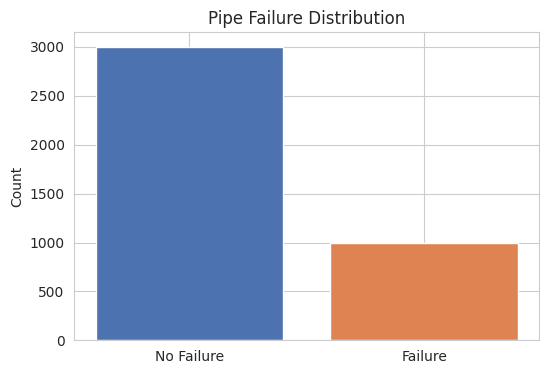

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

counts = df['failure'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['No Failure', 'Failure'], counts.values,
        color=['#4C72B0', '#DD8452'])

plt.title("Pipe Failure Distribution")
plt.ylabel("Count")
plt.show()

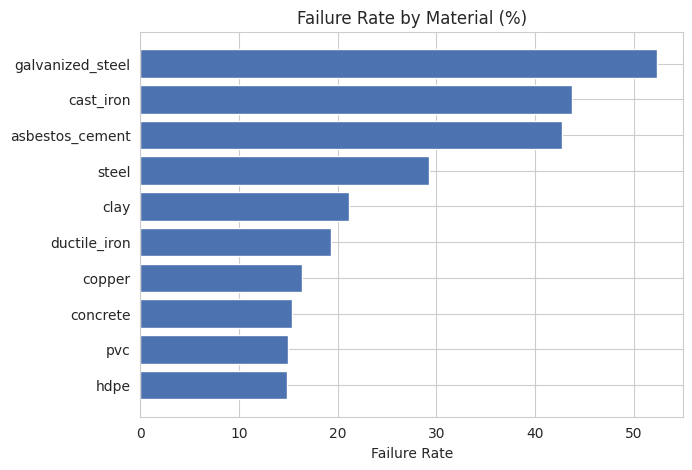

In [6]:
mat_fail = df.groupby('material')['failure'].mean().sort_values() * 100

plt.figure(figsize=(7,5))
plt.barh(mat_fail.index, mat_fail.values, color='#4C72B0')

plt.title("Failure Rate by Material (%)")
plt.xlabel("Failure Rate")
plt.show()

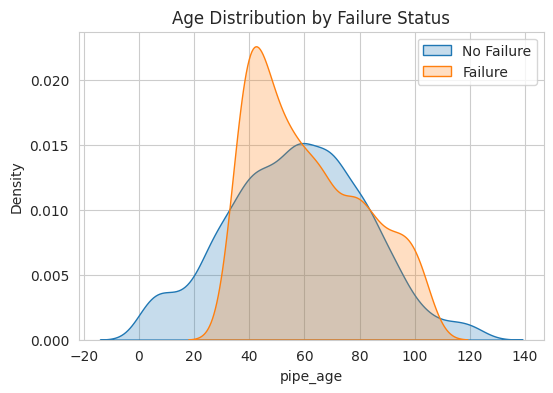

In [7]:
plt.figure(figsize=(6,4))

sns.kdeplot(df[df['failure']==0]['pipe_age'],
            fill=True, label='No Failure')

sns.kdeplot(df[df['failure']==1]['pipe_age'],
            fill=True, label='Failure')

plt.title("Age Distribution by Failure Status")
plt.legend()
plt.show()

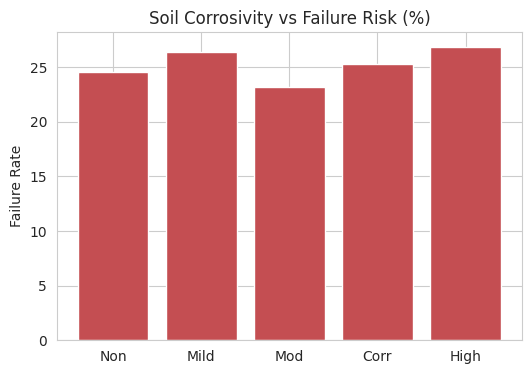

In [8]:
corr_order = ['non_corrosive', 'mildly_corrosive', 'moderately_corrosive',
              'corrosive', 'highly_corrosive']

corr_fail = df.groupby('soil_corrosivity')['failure'].mean().reindex(corr_order) * 100

plt.figure(figsize=(6,4))
plt.bar(['Non','Mild','Mod','Corr','High'], corr_fail.values,
        color='#C44E52')

plt.title("Soil Corrosivity vs Failure Risk (%)")
plt.ylabel("Failure Rate")
plt.show()

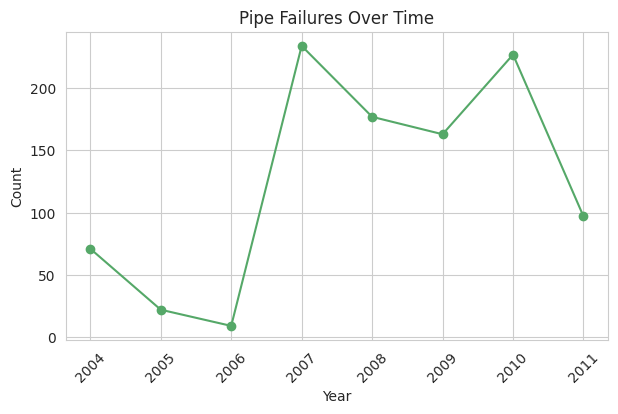

In [9]:
year_counts = syr['year'].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.plot(year_counts.index, year_counts.values,
         marker='o', color='#55A868')

plt.title("Pipe Failures Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

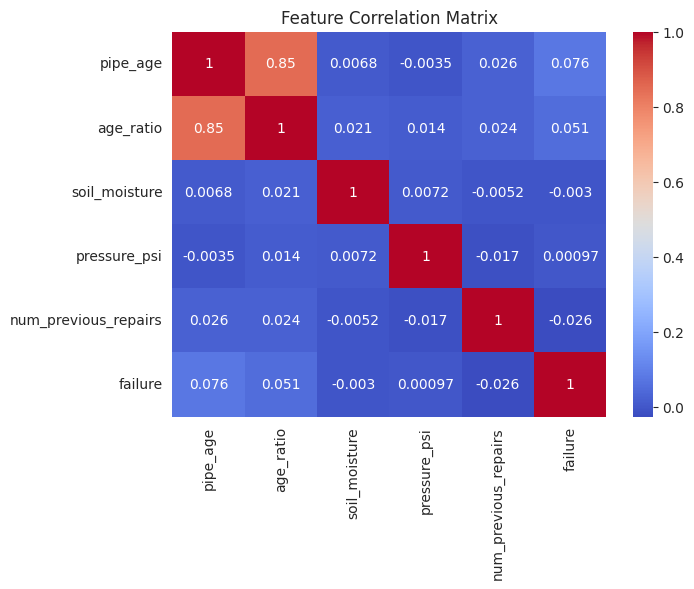

In [10]:
import seaborn as sns

num_cols = ['pipe_age', 'age_ratio', 'soil_moisture',
            'pressure_psi', 'num_previous_repairs', 'failure']

plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

##Feature Engineering

Creating domain-specific derived features from raw pipe data to improve model prediction accuracy. Features include age ratios, soil risk scores, infrastructure stress indices, and composite risk indicators.

In [11]:
def engineer_features(data):
    d = data.copy()

# AGE-BASED FEATURES

    d['pipe_age_sq'] = d['pipe_age'] ** 2  # captures non-linear aging effects
    d['remaining_life'] = np.clip(1 - d['age_ratio'], 0, 1)  # normalized remaining lifespan estimate

    # repair intensity relative to pipe age
    d['repair_frequency'] = d['num_previous_repairs'] / (d['pipe_age'] + 1)

    # stress from pressure relative to pipe diameter
    d['pressure_diam_ratio'] = d['pressure_psi'] / np.maximum(d['diameter_inches'], 1)

# SOIL & ENVIRONMENTAL RISK

    corr_num = d['soil_corrosivity'].map(SOIL_CORROSIVITY_MAP)

    d['soil_risk'] = (
        corr_num * 0.4 +
        (d['soil_moisture'] / 100) * 5 * 0.3 +
        np.abs(d['soil_ph'] - 7) * 0.3
    )

    # operational load on infrastructure
    traffic_num = d['traffic_load'].map({
        'none': 0, 'light': 1, 'moderate': 2, 'heavy': 3
    })

    d['infra_stress'] = (
        traffic_num / 3 * 0.3 +
        d['pressure_psi'] / 120 * 0.3 +
        d['average_daily_flow_gpm'] / 500 * 0.2
    )

    # environmental stress factors
    d['env_stress'] = (
        d['temperature_variation_f'] / 80 * 0.3 +
        d['ground_movement_index'] / 10 * 0.3 +
        d['soil_moisture'] / 100 * 0.2
    )


# BINARY RISK INDICATORS

    d['is_old'] = (d['pipe_age'] > 50).astype(int)
    d['has_repairs'] = (d['num_previous_repairs'] > 0).astype(int)

    d['high_corrosivity'] = d['soil_corrosivity'].isin(
        ['highly_corrosive', 'corrosive']
    ).astype(int)

    d['high_risk_material'] = d['material'].isin(
        ['cast_iron', 'galvanized_steel', 'asbestos_cement']
    ).astype(int)

# COMBINED RISK SCORE

    d['combined_risk'] = (
        d['age_ratio'] * 0.30 +
        d['soil_risk'] / 5 * 0.20 +
        d['repair_frequency'] * 5 * 0.10 +
        d['env_stress'] * 0.15 +
        d['infra_stress'] * 0.10 +
        d['high_risk_material'] * 0.10 +
        d['high_corrosivity'] * 0.05
    )

    return d


# Apply feature engineering
df = engineer_features(df)

# CATEGORICAL ENCODING
cat_cols = ['material', 'soil_type', 'soil_corrosivity', 'traffic_load', 'zone']

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    label_encoders[col] = le

# MODEL PREPARATION
drop_cols = [
    'pipe_id', 'source', 'installation_year',
    'material', 'soil_type', 'soil_corrosivity',
    'traffic_load', 'zone'
]

df_model = df.drop([c for c in drop_cols if c in df.columns], axis=1)

# Target variable
y = df_model['failure']

# Feature matrix
X = df_model.drop('failure', axis=1)
feature_names = X.columns.tolist()


# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# CLASS BALANCING (SMOTE)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# FEATURE SCALING
scaler = StandardScaler()

X_train_bal = pd.DataFrame(
    scaler.fit_transform(X_train_bal),
    columns=feature_names
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

# SUMMARY
print(f"Features: {len(feature_names)}")
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"After SMOTE: {len(X_train_bal)} training samples")

Features: 35
Training samples: 3200 | Test samples: 800
After SMOTE: 4800 training samples


###Training Multiple Models
Three gradient-based and ensemble models are trained and compared: XGBoost, Random Forest, and Gradient Boosting. SMOTE is applied to handle class imbalance in the training data.

In [20]:
models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, eval_metric='logloss',
                              use_label_encoder=False),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15,
                                             random_state=RANDOM_STATE, n_jobs=-1,
                                             class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1,
                                                     random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"{name}: Acc={results[name]['accuracy']:.4f} | F1={results[name]['f1']:.4f} | AUC={results[name]['auc']:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f"\nBest: {best_name} (AUC={results[best_name]['auc']:.4f})")

for name in results:
    print(f"\n{name}:")
    print(classification_report(y_test, results[name]['y_pred'], target_names=['No Failure', 'Failure']))

XGBoost: Acc=0.7325 | F1=0.3631 | AUC=0.6745
Random Forest: Acc=0.7250 | F1=0.3333 | AUC=0.6674
Gradient Boosting: Acc=0.7300 | F1=0.3455 | AUC=0.6733

Best: XGBoost (AUC=0.6745)

XGBoost:
              precision    recall  f1-score   support

  No Failure       0.79      0.88      0.83       600
     Failure       0.45      0.30      0.36       200

    accuracy                           0.73       800
   macro avg       0.62      0.59      0.60       800
weighted avg       0.71      0.73      0.71       800


Random Forest:
              precision    recall  f1-score   support

  No Failure       0.78      0.88      0.83       600
     Failure       0.42      0.28      0.33       200

    accuracy                           0.72       800
   macro avg       0.60      0.57      0.58       800
weighted avg       0.69      0.72      0.70       800


Gradient Boosting:
              precision    recall  f1-score   support

  No Failure       0.79      0.88      0.83       600
     Failure

### Model Evaluation

Comparing model performance through ROC curves, confusion matrices, feature importance rankings, and prediction probability distributions.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

names = list(results.keys())
x = np.arange(len(names))
metrics = ['accuracy', 'f1', 'auc']
bar_width = 0.25

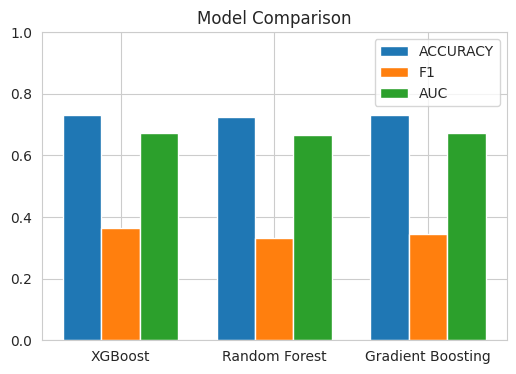

In [14]:
plt.figure(figsize=(6,4))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * bar_width,
        [results[n][metric] for n in names],
        bar_width,
        label=metric.upper()
    )

plt.xticks(x + bar_width, names)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.legend()
plt.show()

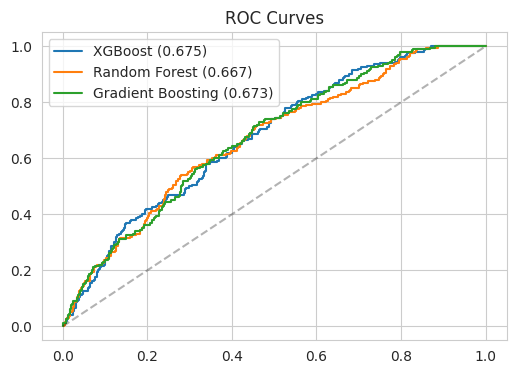

In [15]:
plt.figure(figsize=(6,4))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} ({r['auc']:.3f})")

plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.title("ROC Curves")
plt.legend()
plt.show()

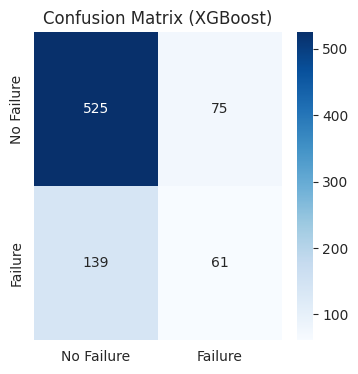

In [16]:
best_name = max(results, key=lambda n: results[n]['auc'])

cm = confusion_matrix(y_test, results[best_name]['y_pred'])

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure','Failure'],
            yticklabels=['No Failure','Failure'])

plt.title(f"Confusion Matrix ({best_name})")
plt.show()

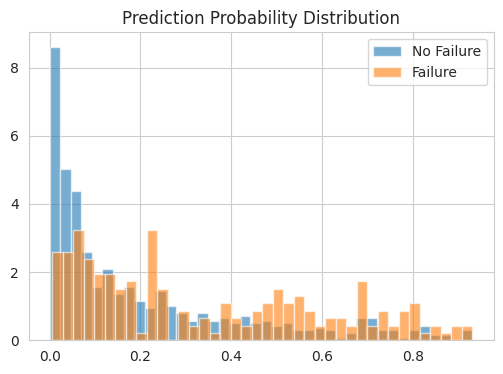

In [17]:
best_name = max(results, key=lambda n: results[n]['auc'])
bp = results[best_name]['y_prob']

plt.figure(figsize=(6,4))

plt.hist(bp[y_test == 0], bins=40, alpha=0.6,
         label='No Failure', density=True)

plt.hist(bp[y_test == 1], bins=40, alpha=0.6,
         label='Failure', density=True)

plt.title("Prediction Probability Distribution")
plt.legend()
plt.show()

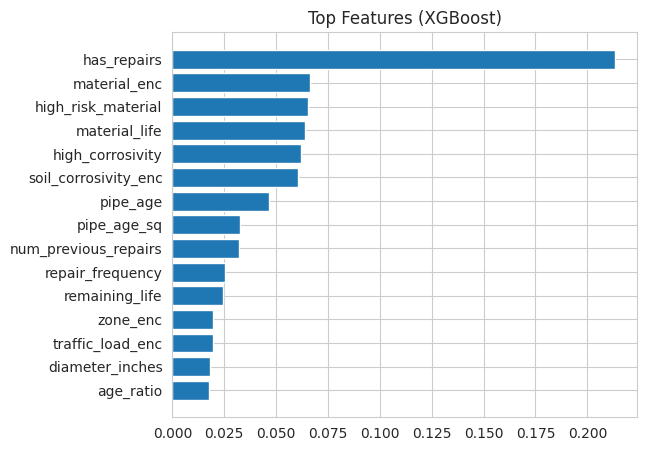

In [18]:
best_name = max(results, key=lambda n: results[n]['auc'])
best_model = results[best_name].get('model', None)

if best_model and hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
    idx = np.argsort(imp)[-15:]

    plt.figure(figsize=(6,5))
    plt.barh(
        [feature_names[i] for i in idx],
        imp[idx]
    )

    plt.title(f"Top Features ({best_name})")
    plt.show()
else:
    print("No feature importance available")

In [19]:
import pandas as pd

table_data = pd.DataFrame([
    {
        "Model": n,
        "Accuracy": results[n]['accuracy'],
        "F1": results[n]['f1'],
        "AUC": results[n]['auc']
    }
    for n in names
])

table_data

,Model,Accuracy,F1,AUC
0,XGBoost,0.7325,0.363095,0.674508
1,Random Forest,0.7250,0.333333,0.667433
2,Gradient Boosting,0.7300,0.345455,0.673292


<p class="usecase-section-header">References</p>

<fn id="fn-1">[1] U.S. Environmental Protection Agency (2024) *Safe Drinking Water Information System (SDWIS) Federal Reporting Services*, EPA ECHO Database. Available at: https://data.epa.gov</fn>

<fn id="fn-2">[2] City of Syracuse (2011) *Water Main Breaks Dataset*, Syracuse Open Data Portal. Available at: https://data.syrgov.net</fn>

<fn id="fn-3">[3] USDA Natural Resources Conservation Service (2024) *Soil Survey Geographic Database (SSURGO)*, Web Soil Survey. Available at: https://websoilsurvey.sc.egov.usda.gov</fn>
